# EDA E-Commerce

Imports

In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Data

In [3]:
df = pd.read_csv("data/online_retail_II.csv")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


First Look at Data

In [4]:
print(df.shape)
print(df.info())
df.describe()

(1067371, 8)
<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB
None


,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


Business Questions

1. What products sell the most?

2. Which countries generate the most revenue?

3. Do we have missing or dirty data?

4. Are there any abnormal transactions?

In [5]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [7]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [8]:
df[df["Quantity"] <= 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [9]:
df[df["Price"] <= 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom


What might negative quantity mean?

Should we delete or separate them?

Why not blindly remove Customer ID nulls?

In [10]:
df[df["Invoice"].str.startswith("C",na=False)]["Quantity"].describe()

count    19494.000000
mean       -25.186827
std        805.104908
min     -80995.000000
25%         -6.000000
50%         -2.000000
75%         -1.000000
max          1.000000
Name: Quantity, dtype: float64

In [11]:
df[~df["Invoice"].str.startswith("C",na=False)]["Quantity"].describe()

count    1.047877e+06
mean     1.059235e+01
std      1.352806e+02
min     -9.600000e+03
25%      1.000000e+00
50%      3.000000e+00
75%      1.000000e+01
max      8.099500e+04
Name: Quantity, dtype: float64

Hypothesis Validation:
Invoice numbers starting with “C” represent credit notes or cancellations.

Upon analysis, these invoices show a strongly negative distribution of quantities (mean ≈ -25), whereas non-“C” invoices show predominantly positive quantities (median = 3).

This validates the hypothesis that “C” invoices correspond to returns and should be treated separately from sales transactions.

STRATEGY
✔ Keep two datasets:

Sales transactions

Returns / cancellations

Why?

Revenue analysis needs clean sales

Returns analysis is a separate business question

In [46]:
sales_df = df[
    (~df["Invoice"].str.startswith("C", na=False)) &
    (df["Quantity"] > 0) &
    (df["Price"] > 0)
]

In [47]:
returns_df = df[
    (df["Invoice"].str.startswith("C", na=False)) |
    (df["Quantity"] <= 0) |
    (df["Price"] <= 0)
]

In [48]:
sales_df["Revenue"] = sales_df["Quantity"] * sales_df["Price"]

In [52]:
sales_df["Revenue"].describe()

count   1,041,670.00
mean           20.13
std           203.12
min             0.00
25%             3.90
50%             9.96
75%            17.70
max       168,469.60
Name: Revenue, dtype: float64

In [63]:
round(sales_df["Revenue"].sum(), 2)

np.float64(20972594.57)

In [65]:
sales_df["Invoice"].nunique()

40077

In [67]:
sales_df["Customer ID"].nunique()

5878

In [90]:
country_revenue = (
    sales_df
    .groupby("Country")["Revenue"]
    .sum()
)

In [102]:
country_revenue.sort_values(ascending=False).head(10)

Country
United Kingdom   17,870,977.78
EIRE                664,431.78
Netherlands         554,232.34
Germany             431,262.46
France              356,944.60
Australia           169,968.11
Spain               109,178.53
Switzerland         101,011.29
Sweden               91,903.72
Denmark              69,862.19
Name: Revenue, dtype: float64

In [98]:
top_products = (
    sales_df
    .groupby("Description")["Revenue"]
    .sum()
)

In [103]:
top_products.sort_values(ascending=False).head(10)

Description
REGENCY CAKESTAND 3 TIER             344,563.25
Manual                               340,731.33
DOTCOM POSTAGE                       322,657.48
WHITE HANGING HEART T-LIGHT HOLDER   266,923.55
PAPER CRAFT , LITTLE BIRDIE          168,469.60
JUMBO BAG RED RETROSPOT              150,935.56
PARTY BUNTING                        149,187.05
ASSORTED COLOUR BIRD ORNAMENT        132,187.92
POSTAGE                              127,597.42
PAPER CHAIN KIT 50'S CHRISTMAS       123,141.54
Name: Revenue, dtype: float64

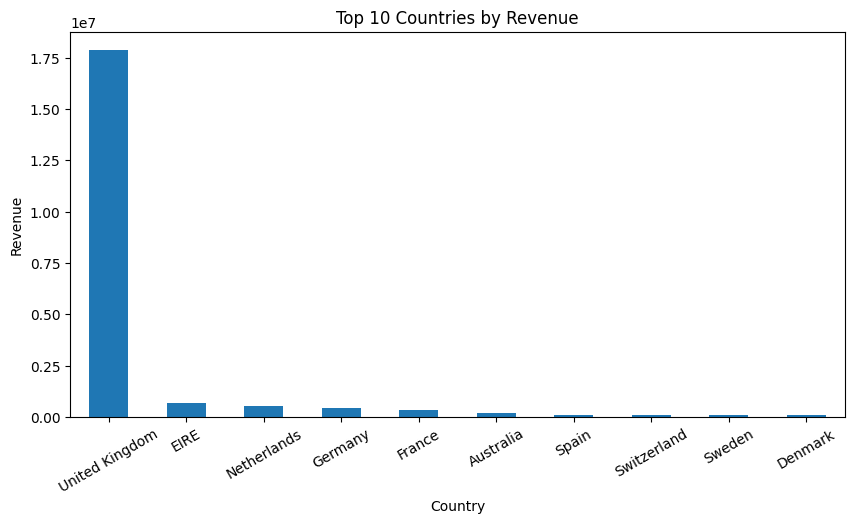

In [134]:
plt.figure(figsize=(10,5))
country_revenue.sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top 10 Countries by Revenue")
plt.ylabel("Revenue")
plt.xticks(rotation=30)
plt.show()

The United Kingdom contributes the majority of total revenue, indicating a strong domestic customer base.

Revenue is highly concentrated among a small number of products, following a Pareto-like distribution.

Non-product entries such as postage also contribute significantly to total revenue.

##Time-Based Analysis

In [135]:
sales_df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,"12,680.00",France,12.60
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,"12,680.00",France,16.60
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,"12,680.00",France,16.60
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,"12,680.00",France,14.85


In [139]:
sales_df["InvoiceMonth"] = sales_df["InvoiceDate"].dt.to_period("M")

In [143]:
sales_df["InvoiceMonth"].sort_values()

0          2009-12
1          2009-12
2          2009-12
3          2009-12
4          2009-12
            ...   
1067366    2011-12
1067367    2011-12
1067368    2011-12
1067369    2011-12
1067370    2011-12
Name: InvoiceMonth, Length: 1041670, dtype: period[M]

In [159]:
sales_df["InvoiceMonth"] = sales_df["InvoiceDate"].dt.to_period("M")

monthly_revenue = (
    sales_df.groupby("InvoiceMonth")["Revenue"]
    .sum()
)

monthly_revenue.head()


InvoiceMonth
2009-12   825,685.76
2010-01   652,708.50
2010-02   553,339.74
2010-03   833,570.13
2010-04   681,528.99
Freq: M, Name: Revenue, dtype: float64

In [160]:
monthly_revenue

InvoiceMonth
2009-12     825,685.76
2010-01     652,708.50
2010-02     553,339.74
2010-03     833,570.13
2010-04     681,528.99
2010-05     659,858.86
2010-06     752,270.14
2010-07     650,712.94
2010-08     697,274.91
2010-09     924,333.01
2010-10   1,165,483.91
2010-11   1,470,272.48
2010-12   1,262,598.79
2011-01     691,364.56
2011-02     523,631.89
2011-03     717,639.36
2011-04     537,808.62
2011-05     770,536.02
2011-06     761,739.90
2011-07     719,221.19
2011-08     759,138.38
2011-09   1,058,590.17
2011-10   1,154,979.30
2011-11   1,509,496.33
2011-12     638,810.68
Freq: M, Name: Revenue, dtype: float64

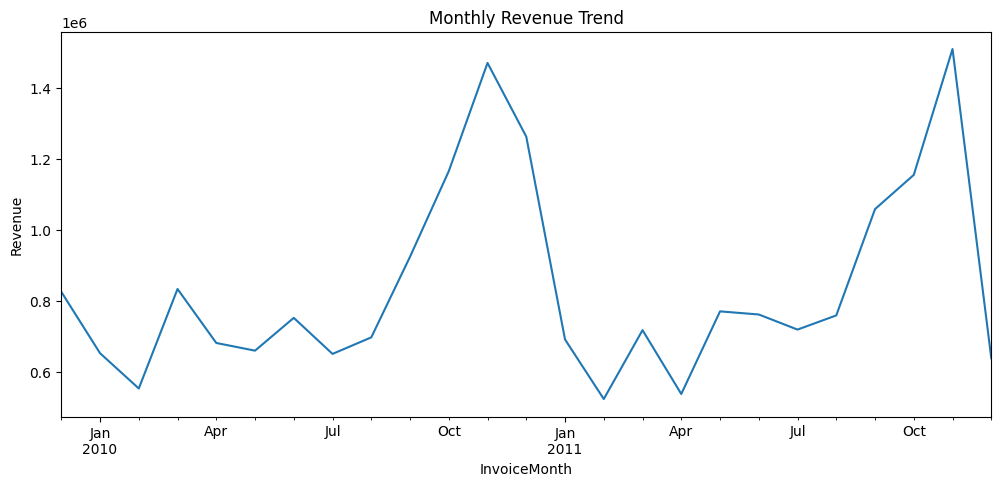

In [158]:
monthly_revenue.plot(figsize=(12,5))
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.show()

Monthly Revenue Trend Analysis:
Revenue shows a clear seasonal pattern, increasing from August and peaking in October–November, likely driven by festive and holiday demand. A sharp decline is observed post-November, continuing into January, indicating a post-holiday slowdown in sales.

Overall Conclusions:

1. Data quality issues handled

2. UK dominance

3. Product revenue concentration

4. Seasonality in Q4

5. Returns treated separately